# ProfitLens — Retail Analytics & Forecasting

Dataset: Superstore Sales (Kaggle)


- Clean the data and understand its structure
- Find which regions are most profitable
- See how discounts affect profit margins
- Forecast profit for the next 30 days

## 1. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install prophet
!pip install scikit-learn


from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('libraries loaded')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


libraries loaded


## 2. Loading the Data

In [ ]:
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')

print('shape:', df.shape)
df.head()

shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:

print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:

print(df.dtypes)

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


## 3. Cleaning the Data

In [6]:
# check for missing values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [7]:
cols_to_drop = ['Row ID', 'Order ID', 'Customer ID', 
                'Customer Name', 'Country', 'City', 'Product ID', 'Product Name']

df = df.drop(columns=cols_to_drop)

In [8]:
# check for duplicate rows
print('duplicates:', df.duplicated().sum())

df = df.drop_duplicates()
print('duplicates after cleaning:', df.duplicated().sum())

duplicates: 1
duplicates after cleaning: 0


In [9]:
# Order Date is string-> converting it to date
df['Order Date'] = pd.to_datetime(df['Order Date'])


df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print('date range:', df['Order Date'].min(), 'to', df['Order Date'].max())
df[['Order Date', 'Year', 'Month']].head()

date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


,Order Date,Year,Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [10]:
# quick summary of key numbers
print('Total rows:', len(df))
print('Total Sales: $', round(df['Sales'].sum(), 2))
print('Total Profit: $', round(df['Profit'].sum(), 2))

Total rows: 9993
Total Sales: $ 2296919.49
Total Profit: $ 286409.08


## 4. Regional Profitability

Which region makes the most profit? 

In [11]:
region_profit = df.groupby('Region')['Profit'].sum()
region_profit = region_profit.sort_values(ascending=False)


print(region_profit)


Region
West       108418.4489
East        91534.8388
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


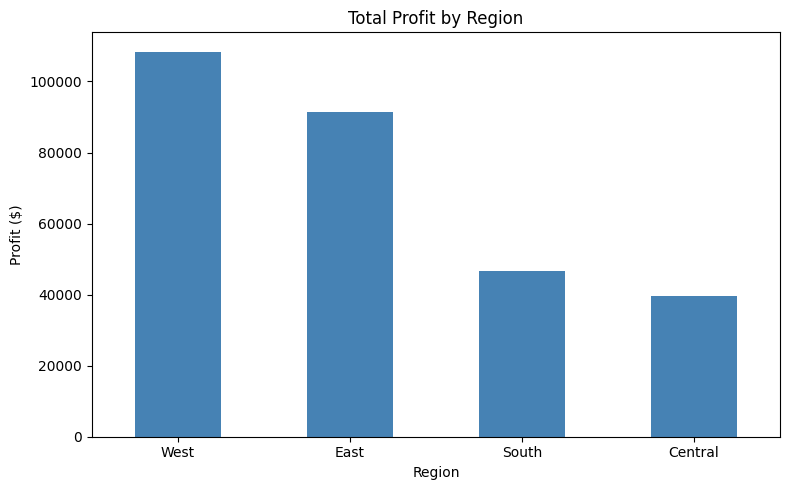

In [12]:
plt.figure(figsize=(8, 5))
region_profit.plot(kind='bar', color='steelblue')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/profit_by_region.png')
plt.show()

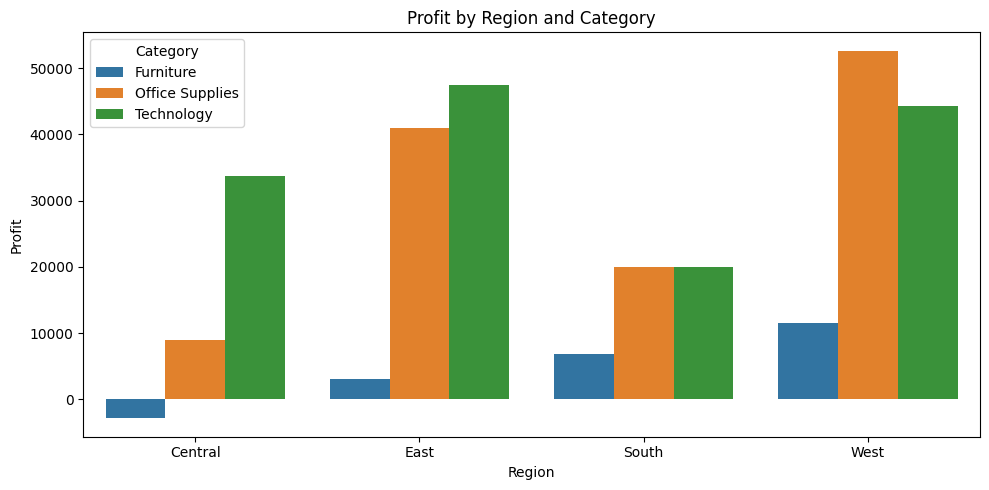

In [13]:
#profit by region and category
region_cat = df.groupby(['Region', 'Category'])['Profit'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=region_cat, x='Region', y='Profit', hue='Category')
plt.title('Profit by Region and Category')
plt.tight_layout()
plt.savefig('../outputs/profit_region_category.png')
plt.show()

## 5. Discount Impact on Profit Margins

Do higher discounts lead to lower profit? 

In [14]:
# profit margin = how much profit we made as a % of sales
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

df[['Sales', 'Profit', 'Discount', 'Profit Margin']].head(10)

,Sales,Profit,Discount,Profit Margin
0,261.9600,41.9136,0.00,16.00
1,731.9400,219.5820,0.00,30.00
2,14.6200,6.8714,0.00,47.00
3,957.5775,-383.0310,0.45,-40.00
4,22.3680,2.5164,0.20,11.25
5,48.8600,14.1694,0.00,29.00
6,7.2800,1.9656,0.00,27.00
7,907.1520,90.7152,0.20,10.00
8,18.5040,5.7825,0.20,31.25
9,114.9000,34.4700,0.00,30.00


In [15]:
#creating discount buckets
bins = [-0.01, 0, 0.2, 0.4, 1.0]
labels = ['No Discount', 'Low (0-20%)', 'Medium (20-40%)', 'High (40%+)']

df['Discount Group'] = pd.cut(df['Discount'], bins=bins, labels=labels)

# average profit margin per group
discount_effect = df.groupby('Discount Group', observed=True)['Profit Margin'].mean()
print(discount_effect)

Discount Group
No Discount         34.016048
Low (0-20%)         17.436785
Medium (20-40%)    -16.712559
High (40%+)       -108.900322
Name: Profit Margin, dtype: float64


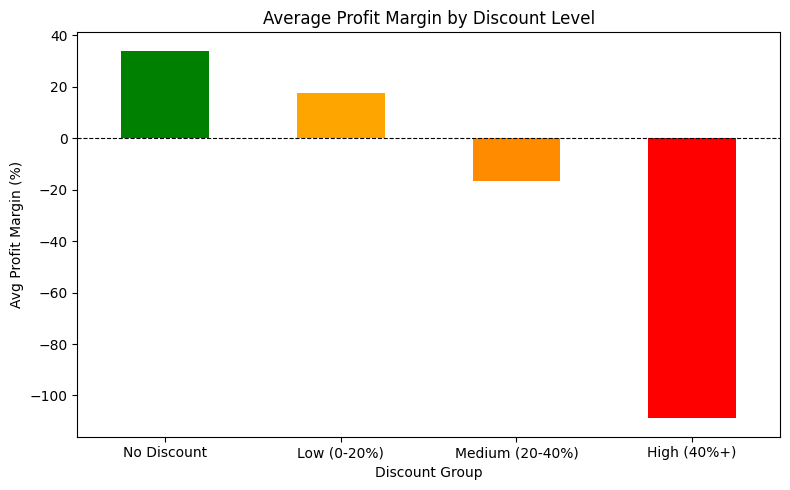

In [16]:
plt.figure(figsize=(8, 5))
discount_effect.plot(kind='bar', color=['green', 'orange', 'darkorange', 'red'])
plt.title('Average Profit Margin by Discount Level')
plt.xlabel('Discount Group')
plt.ylabel('Avg Profit Margin (%)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/discount_impact.png')
plt.show()

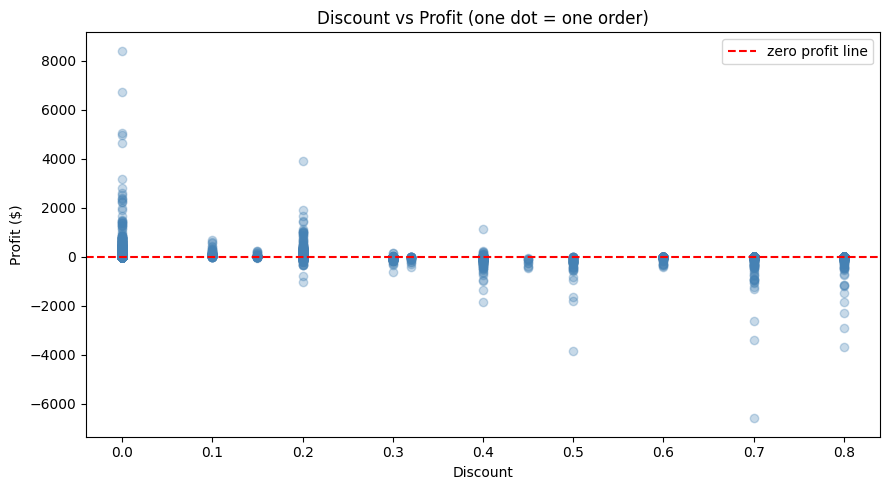

In [17]:
# scatter plot — one dot per order
plt.figure(figsize=(9, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue')
plt.axhline(0, color='red', linestyle='--', label='zero profit line')
plt.title('Discount vs Profit (one dot = one order)')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/discount_scatter.png')
plt.show()

## 6. 30-Day Profit Forecast 


- `ds` = the date
- `y`  = the value to predict (daily profit in our case)

training Prophet on most of the data,
and test it on the last 30 days.

In [18]:
# total profit per day
daily = df.groupby('Order Date')['Profit'].sum().reset_index()

# rename columns 
daily = daily.rename(columns={'Order Date': 'ds', 'Profit': 'y'})

print('days of data:', len(daily))
daily.head()

days of data: 1237


,ds,y
0,2014-01-03,5.5512
1,2014-01-04,-65.9901
2,2014-01-05,4.8840
3,2014-01-06,1358.0524
4,2014-01-07,-71.9621


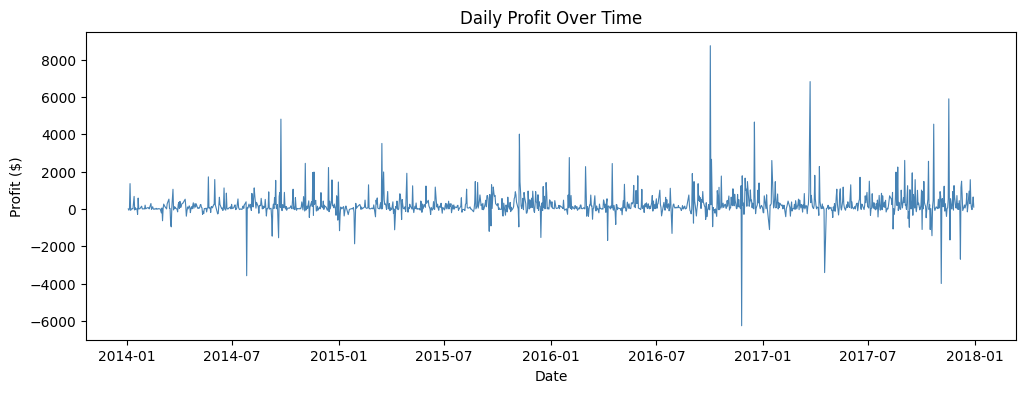

In [19]:
# plot daily profit so we can see the pattern
plt.figure(figsize=(12, 4))
plt.plot(daily['ds'], daily['y'], color='steelblue', linewidth=0.8)
plt.title('Daily Profit Over Time')
plt.xlabel('Date')
plt.ylabel('Profit ($)')
plt.savefig('../outputs/daily_profit.png')
plt.show()

In [20]:
# split into train and test
# train = everything except the last 30 days
# test  = last 30 days 

cutoff = daily['ds'].max() - pd.Timedelta(days=30)

train = daily[daily['ds'] <= cutoff]
test  = daily[daily['ds'] >  cutoff]

print('train size:', len(train), 'days')
print('test size: ', len(test),  'days')

train size: 1208 days
test size:  29 days


In [21]:
# train 
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(train)

print('model trained!')

00:35:47 - cmdstanpy - INFO - Chain [1] start processing
00:35:48 - cmdstanpy - INFO - Chain [1] done processing


model trained!


In [22]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# yhat= predicted profit
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
1228,2017-12-21,512.839116,-408.571364,1385.620685
1229,2017-12-22,481.296970,-401.694781,1395.371990
1230,2017-12-23,442.634977,-436.885206,1322.595178
1231,2017-12-24,507.095011,-404.260265,1378.120623
1232,2017-12-25,468.907745,-341.293495,1319.875521
1233,2017-12-26,388.803156,-474.221830,1349.090487
1234,2017-12-27,315.313680,-605.888110,1266.990033
1235,2017-12-28,398.029939,-541.896848,1242.931077
1236,2017-12-29,358.171736,-475.108062,1221.553892
1237,2017-12-30,313.203233,-569.687775,1221.221663


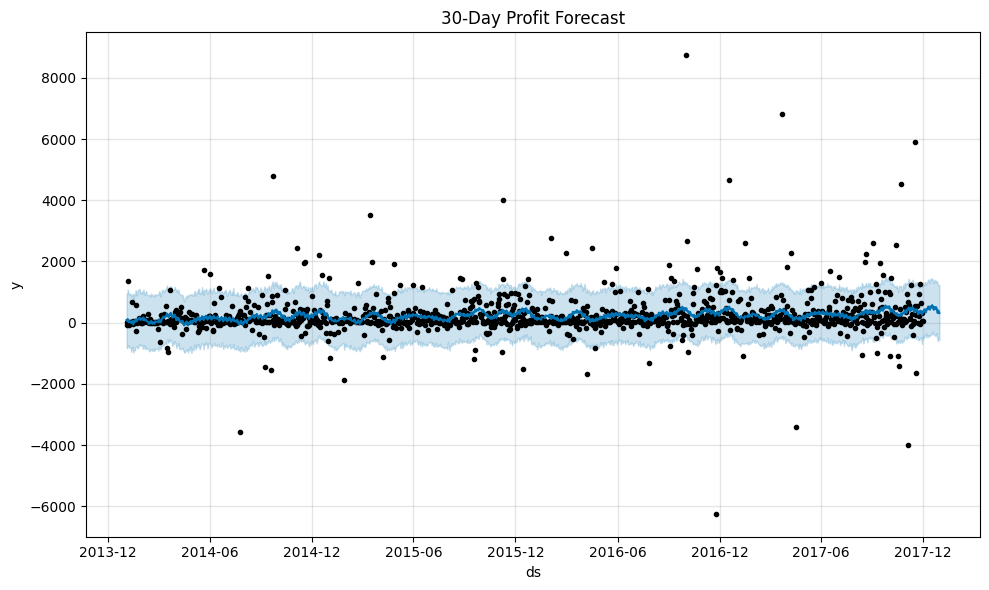

In [23]:
# Prophet's built-in forecast plot
fig = model.plot(forecast)
plt.title('30-Day Profit Forecast')
plt.tight_layout()
plt.savefig('../outputs/forecast.png')
plt.show()

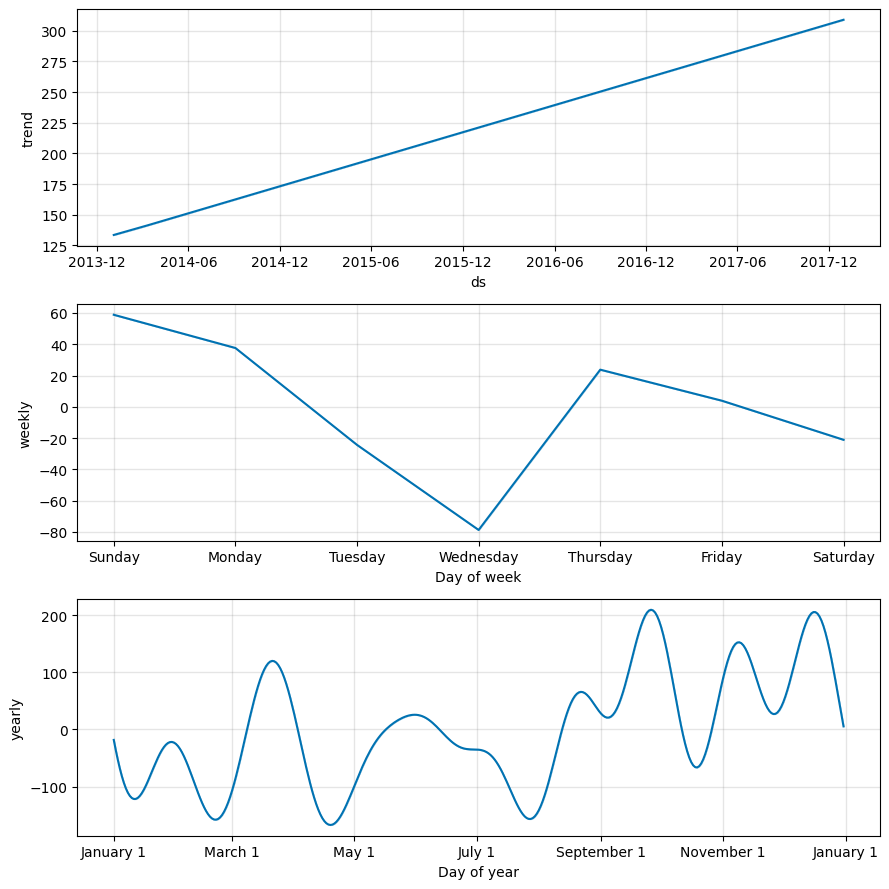

In [24]:
# shows patterns Prophet picked up
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig('../outputs/forecast_components.png')
plt.show()

In [25]:
#accuracy of testing data
eval_df = test.merge(forecast[['ds', 'yhat']], on='ds', how='left').dropna()

mae  = mean_absolute_error(eval_df['y'], eval_df['yhat'])
rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat']))

print(f'MAE  (avg daily error):  ${mae:,.0f}')
print(f'RMSE (penalises big errors more): ${rmse:,.0f}')

MAE  (avg daily error):  $464
RMSE (penalises big errors more): $728


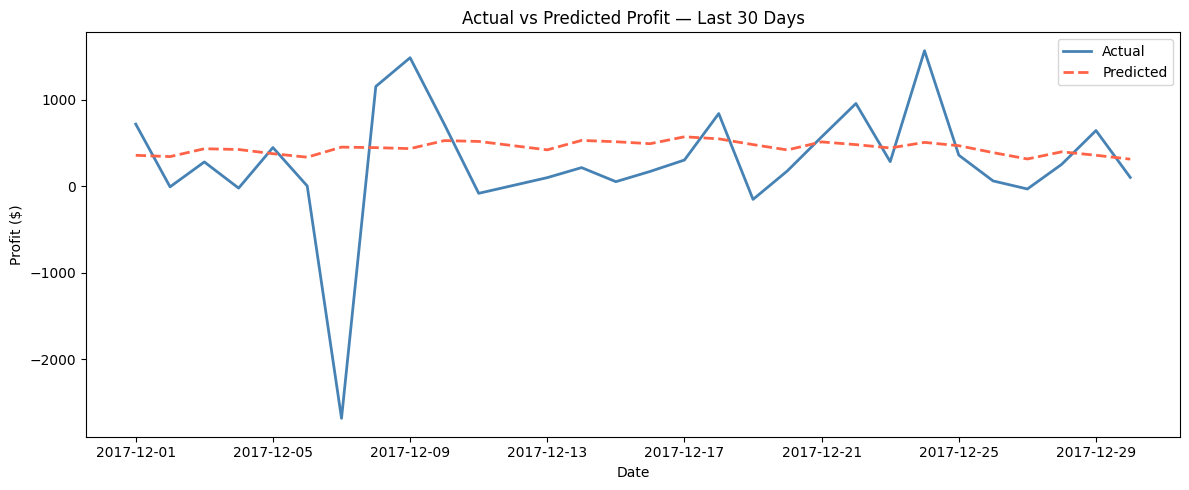

In [26]:
# actual vs predicted 
plt.figure(figsize=(12, 5))
plt.plot(eval_df['ds'], eval_df['y'],    label='Actual',    color='steelblue', linewidth=2)
plt.plot(eval_df['ds'], eval_df['yhat'], label='Predicted', color='tomato',    linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Profit — Last 30 Days')
plt.xlabel('Date')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png')
plt.show()

In [27]:
summary = df.groupby(['Region', 'Category'])[['Sales', 'Profit', 'Discount']].sum().reset_index()

summary.to_csv('summary_for_powerbi.csv', index=False)

print("CSV exported successfully")

CSV exported successfully
